<a href="https://colab.research.google.com/github/rakshatm/Internship/blob/main/Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


In [14]:
# Load the dataset
df = pd.read_csv("sales_data.csv")   # change filename if needed

# Display first 5 rows
df.head()



,Order_Date,Product,Category,Region,Customer_ID,Quantity,Sales
0,2023-01-05,Laptop,Electronics,North,CUST001,2,120000
1,2023-01-08,Mobile,Electronics,South,CUST002,1,30000
2,2023-01-10,Office Chair,Furniture,East,CUST003,3,45000
3,2023-01-15,Desk,Furniture,West,CUST004,1,20000
4,2023-02-03,Tablet,Electronics,North,CUST001,2,50000


In [6]:
# Check dataset info
df.info()

# Check missing values
df.isnull().sum()

# Handle missing values
df['Sales'].fillna(df['Sales'].median(), inplace=True)
df['Quantity'].fillna(df['Quantity'].median(), inplace=True)
df['Region'].fillna(df['Region'].mode()[0], inplace=True)

# Convert Order Date to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Create Month column
df['Month'] = df['Order_Date'].dt.to_period('M')

# Remove duplicates
df.drop_duplicates(inplace=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Order_Date   24 non-null     object
 1   Product      24 non-null     object
 2   Category     24 non-null     object
 3   Region       24 non-null     object
 4   Customer_ID  24 non-null     object
 5   Quantity     24 non-null     int64 
 6   Sales        24 non-null     int64 
dtypes: int64(2), object(5)
memory usage: 1.4+ KB


/tmp/ipython-input-1630157065.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sales'].fillna(df['Sales'].median(), inplace=True)
/tmp/ipython-input-1630157065.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

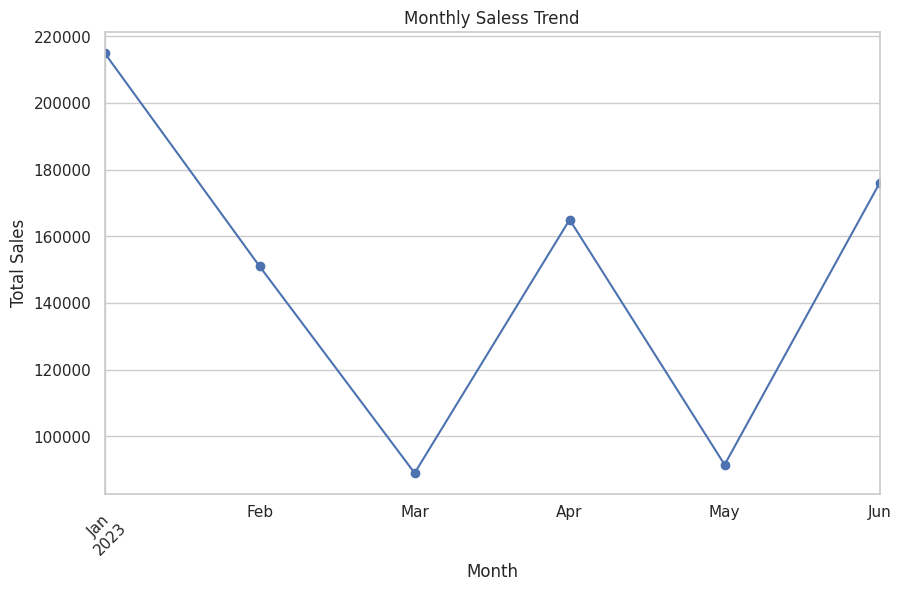

In [7]:
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure()
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Saless Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


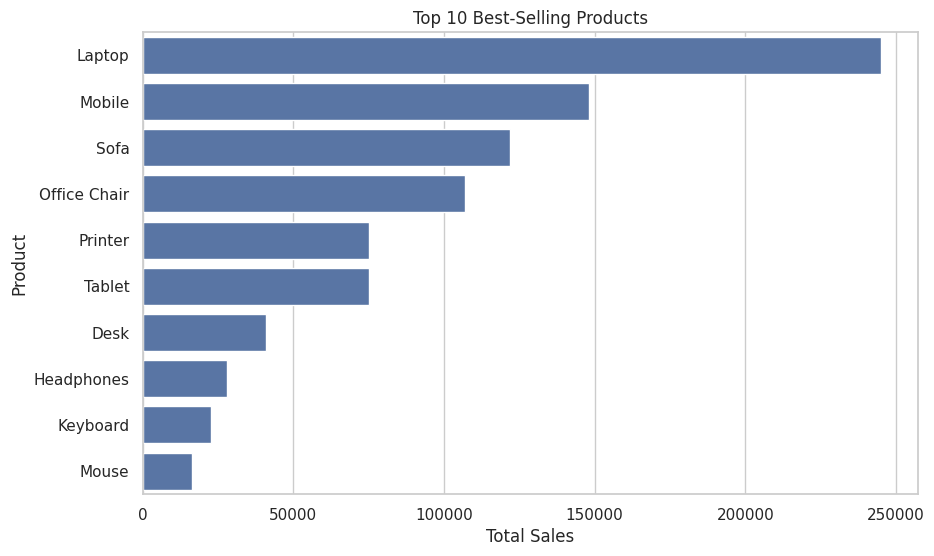

In [8]:
top_products = df.groupby('Product')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure()
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Best-Selling Products")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.show()


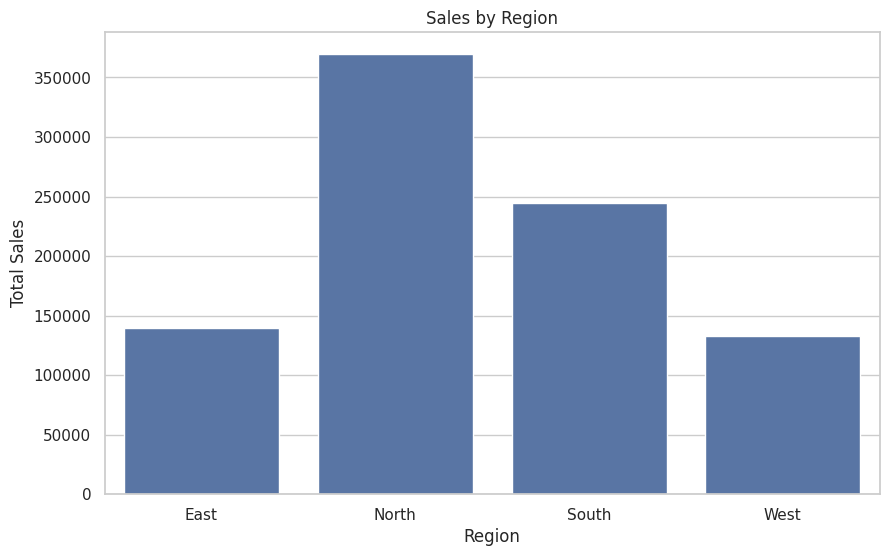

In [9]:
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure()
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()


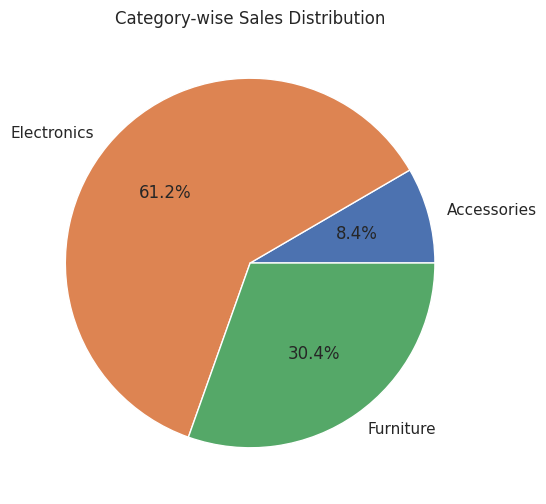

In [10]:
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure()
plt.pie(category_sales, labels=category_sales.index, autopct='%1.1f%%')
plt.title("Category-wise Sales Distribution")
plt.show()


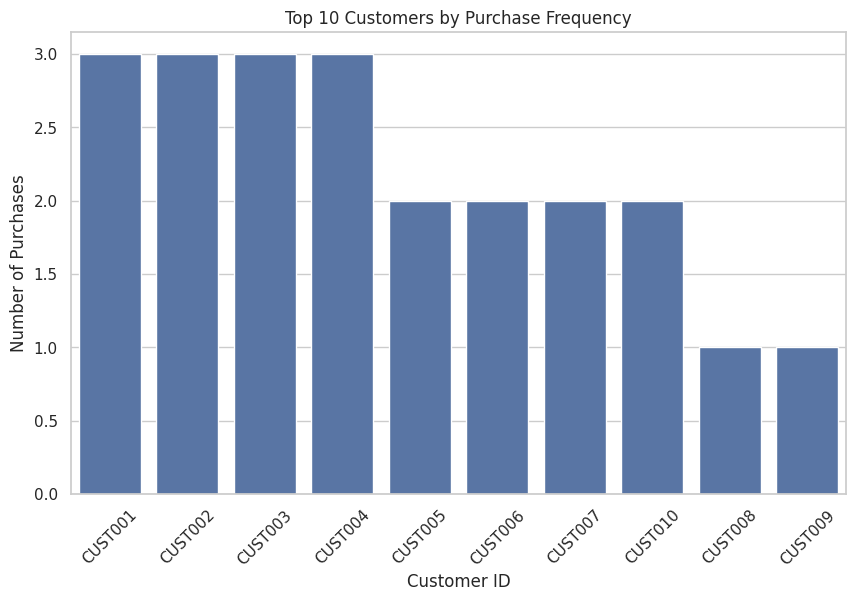

In [11]:
customer_freq = df['Customer_ID'].value_counts().head(10)

plt.figure()
sns.barplot(x=customer_freq.index, y=customer_freq.values)
plt.title("Top 10 Customers by Purchase Frequency")
plt.xlabel("Customer ID")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=45)
plt.show()
